# Moving Average Crossover Failure Audit

이 노트북은 **이동평균 교차 전략(Moving Average Crossover)**이 왜 횡보장과 전환 구간에서 깨지는지 확인한다.

목표는 다음과 같다.

1. 프로젝트에 구현된 MA Crossover 코드와 수식을 연결해 이해한다.
2. 가짜 데이터로 추세장/횡보장/데드캣 바운스에서 신호가 어떻게 달라지는지 확인한다.
3. 실제 Binance BTCUSDT perpetual 체결 데이터로 MA Crossover 신호와 백테스트 결과를 확인한다.
4. 왜 이후 전략을 Price Box/OI Box 기반 시장 상태 필터로 확장했는지 설명한다.

코드 위치:

`research/backtests/microstructure/strategies/moving_average_crossover.py`

## 1. Strategy Formula

단순 이동평균은 다음과 같이 계산한다.

$$
SMA_t(n)=\frac{1}{n}\sum_{i=0}^{n-1}P_{t-i}
$$

프로젝트 기본값은 다음과 같다.

- `fast_window = 20`
- `slow_window = 80`
- `neutral_band_bps = 2.0`

Long 조건:

$$
SMA_{fast,t} > SMA_{slow,t}\times(1+band)
$$

Short 조건:

$$
SMA_{fast,t} < SMA_{slow,t}\times(1-band)
$$

여기서 `band`는 bps 단위를 비율로 바꾼 값이다.

$$
band=\frac{neutral\_band\_bps}{10,000}
$$

예를 들어 `neutral_band_bps=2`라면:

$$
band=\frac{2}{10,000}=0.0002=0.02\%
$$

즉, Fast MA와 Slow MA가 아주 조금 차이 나는 구간은 추세로 보지 않기 위한 완충지대다.

## 2. Why It Breaks in Range Markets

MA Crossover는 추세가 길게 이어지면 잘 작동한다. 하지만 횡보장에서는 Fast MA가 Slow MA를 반복적으로 위아래로 교차한다.

```text
Range Market
가격:    100 → 101 → 99 → 101 → 99 → 100
Fast MA: 민감하게 위아래 이동
Slow MA: 완만하게 유지
결과:    Long → Short → Long → Short 반복
```

문제는 다음과 같다.

- 추세가 없는데 신호가 계속 바뀐다.
- 포지션 전환이 많아져 수수료와 슬리피지가 누적된다.
- 큰 하락 후 데드캣 바운스 같은 반대 흐름을 새로운 추세로 오인할 수 있다.
- 이동평균은 후행 지표라 방향 전환을 늦게 감지한다.

## 3. Setup

In [1]:
from pathlib import Path
import os
import sys
from dataclasses import dataclass

import numpy as np
import pandas as pd
import polars as pl
import matplotlib.pyplot as plt
from IPython.display import Markdown, display

PROJECT_ROOT = Path.cwd()
while PROJECT_ROOT.name != 'takora-trading' and PROJECT_ROOT.parent != PROJECT_ROOT:
    PROJECT_ROOT = PROJECT_ROOT.parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

DATA_ROOT = Path(os.environ.get('TAKORA_DATA_ROOT', '/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))
OUTPUT_DIR = PROJECT_ROOT / 'research/notebooks/_outputs'
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

from research.backtests.microstructure.strategies.moving_average_crossover import generate_moving_average_crossover_signals
from research.backtests.microstructure.metrics import compute_all_metrics

pd.set_option('display.max_columns', 100)
pd.set_option('display.width', 180)
plt.style.use('seaborn-v0_8-whitegrid')

PROJECT_ROOT, DATA_ROOT

(PosixPath('/Users/changminkim/Desktop/projects/equidice/takora-trading'),
 PosixPath('/Users/changminkim/Desktop/projects/equidice/datasets/exchange'))

## 4. Setting Functions

In [2]:
@dataclass(frozen=True)
class CloseBar:
    close_price: float


def add_ma_crossover_features(
    df: pd.DataFrame,
    *,
    price_col: str = 'close',
    fast_window: int = 20,
    slow_window: int = 80,
    neutral_band_bps: float = 2.0,
    exit_on_neutral: bool = False,
) -> pd.DataFrame:
    out = df.copy()
    bars = [CloseBar(float(v)) for v in out[price_col].to_numpy()]
    out['signal'] = generate_moving_average_crossover_signals(
        bars,
        fast_window=fast_window,
        slow_window=slow_window,
        neutral_band_bps=neutral_band_bps,
        exit_on_neutral=exit_on_neutral,
        force_flat_last=True,
    )
    out['fast_ma'] = out[price_col].rolling(fast_window).mean()
    out['slow_ma'] = out[price_col].rolling(slow_window).mean()
    band = neutral_band_bps / 10_000.0
    out['long_threshold'] = out['slow_ma'] * (1.0 + band)
    out['short_threshold'] = out['slow_ma'] * (1.0 - band)
    out['neutral_zone_width_bps'] = neutral_band_bps * 2
    out['signal_change'] = out['signal'].diff().fillna(0).ne(0)
    out['log_return'] = np.log(out[price_col]).diff().fillna(0.0)
    return out


def extract_position_trades(frame: pd.DataFrame, *, price_col='close', initial_equity=10_000.0, notional=1_000.0, cost_bps=7.0) -> pd.DataFrame:
    rows = []
    current = None
    for row in frame.itertuples(index=False):
        ts = getattr(row, 'timestamp')
        price = float(getattr(row, price_col))
        signal = int(getattr(row, 'position'))
        prev_signal = int(getattr(row, 'prev_position'))
        if current is not None and signal != prev_signal:
            direction = current['direction']
            gross = direction * notional * (price / current['entry_price'] - 1.0)
            cost = notional * cost_bps / 10_000.0
            rows.append({
                'entry_time': current['entry_time'],
                'exit_time': ts,
                'direction': direction,
                'entry_price': current['entry_price'],
                'exit_price': price,
                'gross_pnl': gross,
                'cost': current['entry_cost'] + cost,
                'pnl': gross - current['entry_cost'] - cost,
            })
            current = None
        if current is None and signal != 0 and signal != prev_signal:
            current = {
                'entry_time': ts,
                'direction': signal,
                'entry_price': price,
                'entry_cost': notional * cost_bps / 10_000.0,
            }
    return pd.DataFrame(rows)


def run_vector_ma_backtest(
    df: pd.DataFrame,
    *,
    price_col: str = 'close',
    initial_equity: float = 10_000.0,
    notional: float = 1_000.0,
    cost_bps: float = 7.0,
) -> tuple[pd.DataFrame, pd.DataFrame, dict[str, float]]:
    out = df.copy().sort_values('timestamp').reset_index(drop=True)
    out['position'] = out['signal'].shift(1).fillna(0).astype(int)
    out['prev_position'] = out['position'].shift(1).fillna(0).astype(int)
    out['turnover'] = (out['position'] - out['prev_position']).abs()
    out['strategy_gross_pnl'] = out['position'] * notional * out['log_return']
    out['cost'] = out['turnover'] * notional * cost_bps / 10_000.0
    out['strategy_pnl'] = out['strategy_gross_pnl'] - out['cost']
    out['equity'] = initial_equity + out['strategy_pnl'].cumsum()
    out['drawdown'] = out['equity'] / out['equity'].cummax() - 1.0
    trades = extract_position_trades(out, price_col=price_col, initial_equity=initial_equity, notional=notional, cost_bps=cost_bps)
    trade_pnls = trades['pnl'].tolist() if not trades.empty else []
    metrics = compute_all_metrics(out['equity'].tolist(), trade_pnls, periods_per_year=365 * 24 * 12)
    metrics.update({
        'signal_flips': float(out['signal_change'].sum()),
        'long_bars': float((out['signal'] == 1).sum()),
        'short_bars': float((out['signal'] == -1).sum()),
        'flat_bars': float((out['signal'] == 0).sum()),
        'total_cost_paid': float(out['cost'].sum()),
    })
    return out, trades, metrics


def metrics_table(metrics_by_name: dict[str, dict[str, float]]) -> pd.DataFrame:
    rows = []
    for name, m in metrics_by_name.items():
        rows.append({
            'scenario': name,
            'total_return_pct': m.get('total_return', np.nan) * 100,
            'win_rate_pct': m.get('win_rate', np.nan) * 100,
            'profit_factor': m.get('profit_factor', np.nan),
            'max_drawdown_pct': m.get('max_drawdown', np.nan) * 100,
            'total_trades': m.get('total_trades', np.nan),
            'signal_flips': m.get('signal_flips', np.nan),
            'total_cost_paid': m.get('total_cost_paid', np.nan),
        })
    return pd.DataFrame(rows)

## 5. Fake Data: Trend vs Range vs Dead-cat Bounce

먼저 가짜 데이터로 MA Crossover의 성격을 확인한다.

- `trend_up`: 완만한 상승 추세
- `range_chop`: 박스권 안에서 위아래로 흔들리는 횡보장
- `deadcat_after_drop`: 큰 하락 후 짧은 반등이 나타나는 구간

In [22]:
def make_synthetic_market(n: int = 360, seed: int = 7) -> pd.DataFrame:
    rng = np.random.default_rng(seed)
    ts = pd.date_range('2026-01-01', periods=n, freq='5min')

    trend = 100 + np.linspace(0, 18, n) + rng.normal(0, 0.35, n)
    range_chop = 100 + 2.0 * np.sin(np.arange(n) / 5.0) + rng.normal(0, 0.55, n)

    deadcat = np.empty(n)
    deadcat[:120] = 100 + rng.normal(0, 0.35, 120)
    deadcat[120:170] = np.linspace(100, 84, 50) + rng.normal(0, 0.45, 50)
    deadcat[170:230] = np.linspace(84, 92, 60) + rng.normal(0, 0.50, 60)
    deadcat[230:] = np.linspace(92, 82, n - 230) + rng.normal(0, 0.55, n - 230)

    frames = []
    for name, close in [('trend_up', trend), ('range_chop', range_chop), ('deadcat_after_drop', deadcat)]:
        frames.append(pd.DataFrame({'timestamp': ts, 'scenario': name, 'close': close}))
    return pd.concat(frames, ignore_index=True)

synthetic = make_synthetic_market()
synthetic.head()

,timestamp,scenario,close
0,2026-01-01 00:00:00,trend_up,100.000431
1,2026-01-01 00:05:00,trend_up,100.154700
2,2026-01-01 00:10:00,trend_up,100.004330
3,2026-01-01 00:15:00,trend_up,99.838711
4,2026-01-01 00:20:00,trend_up,100.041422


In [ ]:
synthetic_results = {}
synthetic_trades = {}
synthetic_metrics = {}

for scenario, group in synthetic.groupby('scenario'):
    features = add_ma_crossover_features(
        group.reset_index(drop=True),
        fast_window=20,
        slow_window=80,
        neutral_band_bps=2.0,
        exit_on_neutral=False,
    )
    result, trades, metrics = run_vector_ma_backtest(features, notional=1_000.0, cost_bps=7.0)
    synthetic_results[scenario] = result
    synthetic_trades[scenario] = trades
    synthetic_metrics[scenario] = metrics

synthetic_summary = metrics_table(synthetic_metrics)
synthetic_summary

,scenario,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades,signal_flips,total_cost_paid
0,deadcat_after_drop,1.961827,75.0,6.041086,-0.732059,4.0,6.0,6.3
1,range_chop,-7.155314,0.0,0.000000,-7.155314,18.0,20.0,25.9
2,trend_up,1.206036,0.0,0.000000,-0.114406,0.0,2.0,0.7


가짜 데이터에서는 보통 상승 추세 구간보다 횡보장과 dead-cat 구간에서 signal flip과 비용 부담이 커진다. 특히 `range_chop`은 가격이 박스 안에서 왕복하기 때문에 Fast MA와 Slow MA가 반복적으로 교차하고, 이때 포지션 전환이 많아진다.

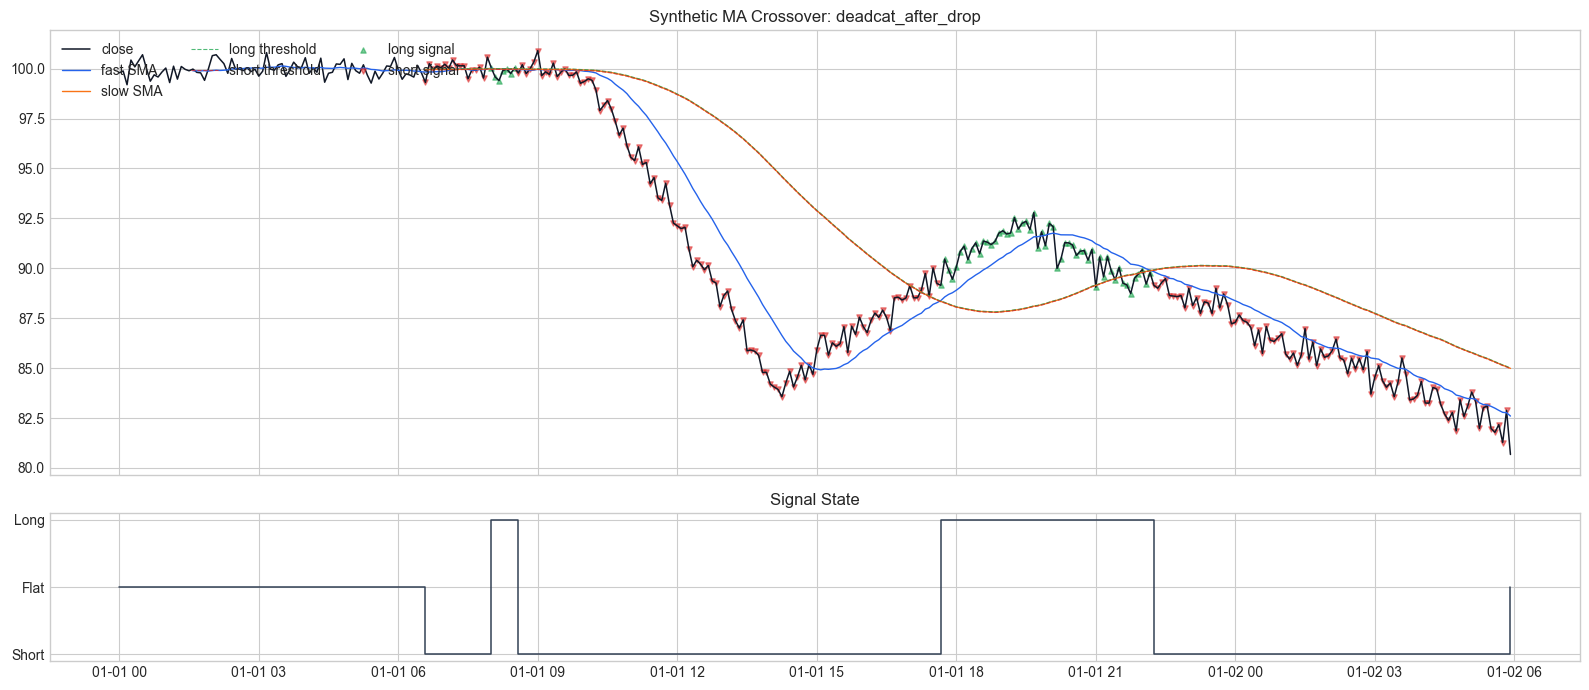

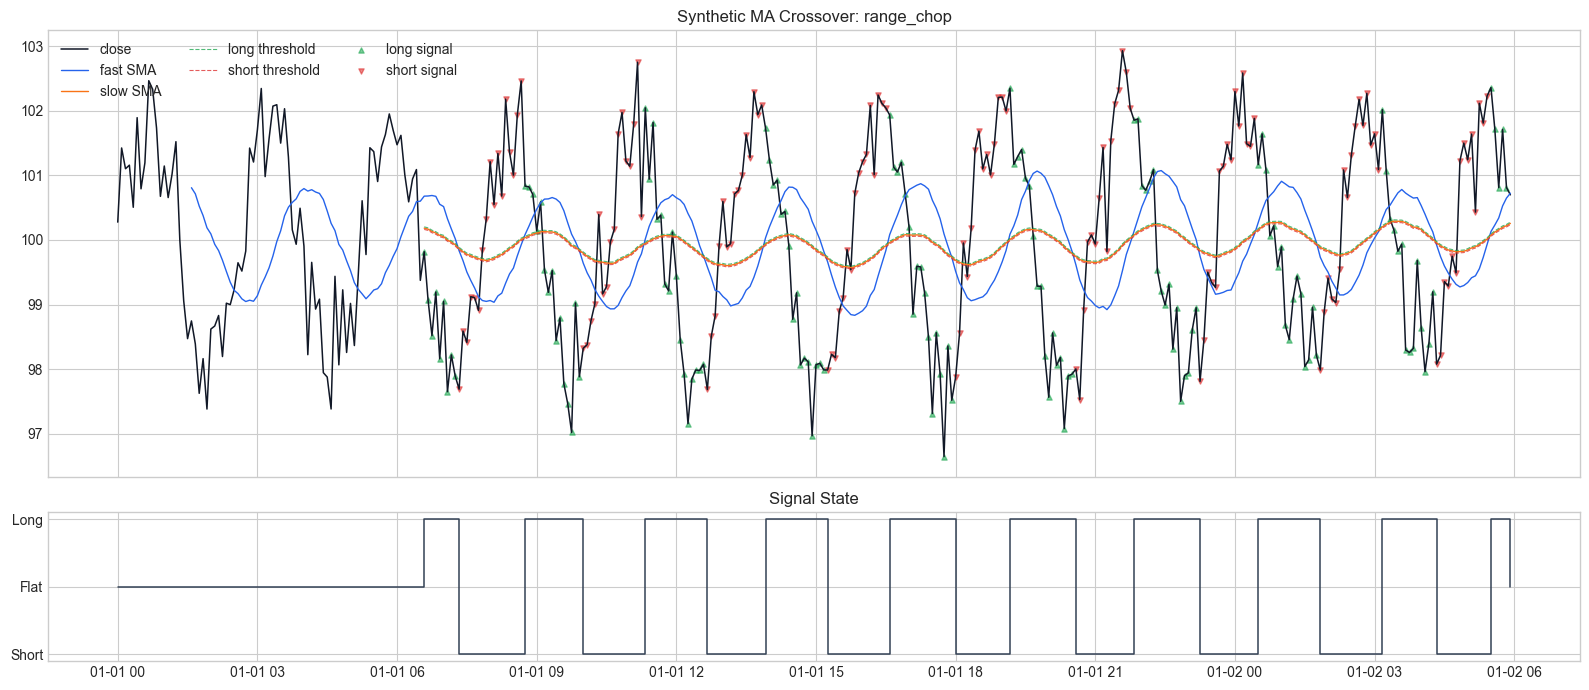

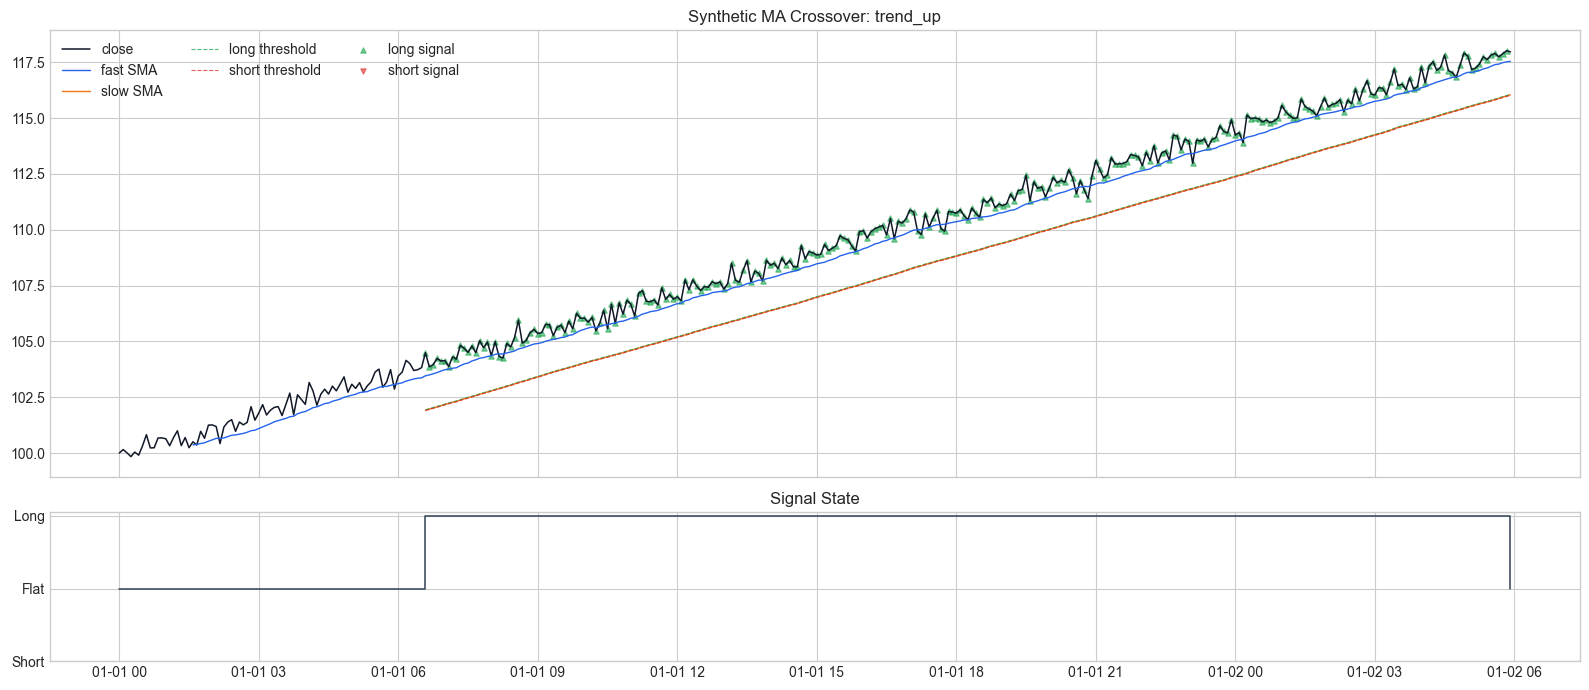

In [5]:
def plot_ma_signal_panel(frame: pd.DataFrame, title: str):
    fig, axes = plt.subplots(2, 1, figsize=(16, 7), sharex=True, gridspec_kw={'height_ratios': [3, 1]})
    ax = axes[0]
    ax.plot(frame['timestamp'], frame['close'], color='#111827', linewidth=1.1, label='close')
    ax.plot(frame['timestamp'], frame['fast_ma'], color='#2563EB', linewidth=1.0, label='fast SMA')
    ax.plot(frame['timestamp'], frame['slow_ma'], color='#F97316', linewidth=1.0, label='slow SMA')
    ax.plot(frame['timestamp'], frame['long_threshold'], color='#16A34A', linestyle='--', linewidth=0.8, alpha=0.75, label='long threshold')
    ax.plot(frame['timestamp'], frame['short_threshold'], color='#DC2626', linestyle='--', linewidth=0.8, alpha=0.75, label='short threshold')

    longs = frame[frame['signal'] == 1]
    shorts = frame[frame['signal'] == -1]
    ax.scatter(longs['timestamp'], longs['close'], marker='^', s=14, color='#16A34A', alpha=0.55, label='long signal')
    ax.scatter(shorts['timestamp'], shorts['close'], marker='v', s=14, color='#DC2626', alpha=0.55, label='short signal')
    ax.set_title(title)
    ax.legend(loc='upper left', ncol=3)

    axes[1].step(frame['timestamp'], frame['signal'], where='post', color='#334155', linewidth=1.1)
    axes[1].set_yticks([-1, 0, 1])
    axes[1].set_yticklabels(['Short', 'Flat', 'Long'])
    axes[1].set_title('Signal State')
    plt.tight_layout()
    return fig, axes

for scenario, frame in synthetic_results.items():
    fig, axes = plot_ma_signal_panel(frame, f'Synthetic MA Crossover: {scenario}')
    plt.show()

상승 추세 구간에서는 Fast MA가 Slow MA 위에 머물면서 Long 신호가 비교적 안정적으로 유지된다. 이때 MA Crossover의 장점이 잘 드러난다.

반대로 횡보장에서는 가격이 박스 안에서 왕복하며 Fast MA가 Slow MA 주변을 계속 오간다. 이 때문에 Long/Short 전환이 잦아지고, 실제 방향성은 없는데 거래비용이 누적된다.

Dead-cat 예시에서는 큰 하락 이후 반등 구간에서 Fast MA가 늦게 반응한다. 짧은 반등을 추세 전환으로 오인하거나, 반등이 끝난 뒤에도 신호가 늦게 바뀌는 모습을 확인할 수 있다. =>  MA Crossover는 과거 가격 평균을 쓰는 후행 지표이기 때문에, 반등 초반에는 신호가 늦고 반등이 끝난 뒤에도 이전 평균의 영향으로 포지션 전환이 늦어질 수 있다.

## 6. Real Binance Data

이제 실제 Binance BTCUSDT perpetual 체결 데이터를 5분봉 OHLCV로 집계한다.

기본 구간은 포트폴리오에서 자주 확인했던 `2026-06-22 ~ 2026-06-28`로 잡았다. 이 구간에는 큰 하락, 반등, 방향 전환이 함께 포함되어 있어 해당 구간을 잡았다.

In [6]:
START_TIME = '2026-06-22 00:00:00'
END_TIME = '2026-06-28 23:55:00'
BAR_SIZE = '5m'


def date_filtered_paths(root: Path, pattern: str, start: pd.Timestamp, end: pd.Timestamp) -> list[Path]:
    paths = sorted(root.glob(pattern))
    dates = set(pd.date_range(start.normalize(), end.normalize(), freq='D').strftime('%Y-%m-%d'))
    selected = [path for path in paths if any(date in path.name for date in dates)]
    return selected if selected else paths


def load_binance_trades_ohlcv(
    *,
    data_root: Path = DATA_ROOT,
    start: str | pd.Timestamp = START_TIME,
    end: str | pd.Timestamp = END_TIME,
    bar_size: str = BAR_SIZE,
) -> pd.DataFrame:
    start = pd.Timestamp(start)
    end = pd.Timestamp(end)
    paths = date_filtered_paths(
        data_root,
        'binance/assets/btcusdt/future/trades/hour/*.parquet',
        start,
        end,
    )
    if not paths:
        raise FileNotFoundError('No Binance trades parquet files found')

    lf = (
        pl.scan_parquet([str(path) for path in paths])
        .with_columns([
            pl.from_epoch(pl.col('trade_time'), time_unit='ms').alias('timestamp'),
            pl.col('price').cast(pl.Float64, strict=False).alias('price'),
            pl.col('quantity').cast(pl.Float64, strict=False).alias('quantity'),
        ])
        .filter(pl.col('timestamp') >= start.to_pydatetime())
        .filter(pl.col('timestamp') <= end.to_pydatetime())
        .drop_nulls(['timestamp', 'price', 'quantity'])
        .filter((pl.col('price') > 0) & (pl.col('quantity') > 0))
        .sort('timestamp')
        .group_by_dynamic('timestamp', every=bar_size, period=bar_size)
        .agg([
            pl.col('price').first().alias('open'),
            pl.col('price').max().alias('high'),
            pl.col('price').min().alias('low'),
            pl.col('price').last().alias('close'),
            pl.col('quantity').sum().alias('volume'),
            pl.len().alias('trade_count'),
        ])
    )
    out = lf.collect().to_pandas()
    out['timestamp'] = pd.to_datetime(out['timestamp']).astype('datetime64[ns]')
    return out.dropna(subset=['open', 'high', 'low', 'close']).sort_values('timestamp').reset_index(drop=True)

price_df = load_binance_trades_ohlcv()
print('rows:', len(price_df))
print('range:', price_df['timestamp'].min(), '->', price_df['timestamp'].max())
price_df.head()

rows: 2015
range: 2026-06-22 00:00:00 -> 2026-06-28 23:50:00


,timestamp,open,high,low,close,volume,trade_count
0,2026-06-22 00:00:00,63287.2,63448.0,63286.2,63407.8,900.144,23647
1,2026-06-22 00:05:00,63408.0,63555.0,63400.8,63549.1,829.836,20188
2,2026-06-22 00:10:00,63549.1,63569.4,63402.9,63482.4,368.233,12219
3,2026-06-22 00:15:00,63482.3,63737.8,63471.7,63613.0,750.866,21204
4,2026-06-22 00:20:00,63612.9,63650.0,63517.8,63628.0,530.454,15358


## 7. Real Data: MA Signal and Backtest

In [7]:
ma_df = add_ma_crossover_features(
    price_df,
    fast_window=20,
    slow_window=80,
    neutral_band_bps=2.0,
    exit_on_neutral=False,
)
ma_result, ma_trades, ma_metrics = run_vector_ma_backtest(
    ma_df,
    initial_equity=10_000.0,
    notional=1_000.0,
    cost_bps=7.0,
)

real_summary = metrics_table({'ma_crossover': ma_metrics})
real_summary

,scenario,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades,signal_flips,total_cost_paid
0,ma_crossover,-0.367644,25.806452,0.616924,-0.80783,31.0,33.0,44.1


실제 Binance 5분봉 구간에서 MA Crossover 단독 전략은 다음과 같이 나왔다.

| Metric | Value |
|---|---:|
| Total Return | **-0.37%** |
| Win Rate | **25.81%** |
| Profit Factor | **0.62** |
| Max Drawdown | **-0.81%** |
| Total Trades | **31회** |
| Signal Flips | **33회** |
| Total Cost Paid | **44.1** |

핵심은 수익률이 소폭 음수라는 점보다, **승률 25.8%와 PF 0.62**가 보여주는 거래 품질이다. 수익 거래보다 손실 거래가 훨씬 많았고, 손실 합계가 수익 합계보다 컸기 때문에 전략 자체의 기대값이 좋지 않았다.

또한 거래 수 31회 대비 signal flip이 33회로 나타났다. 이는 해당 구간에서 MA 신호가 안정적으로 한 방향을 유지했다기보다, 가격 변화에 따라 포지션 방향이 자주 바뀌었다는 뜻이다. 5분봉 전략에서는 이런 신호 전환이 수수료, 슬리피지, 스프레드 비용으로 바로 누적된다.

따라서 이 결과는 MA Crossover가 완전히 쓸모없다는 의미가 아니라, **시장 상태를 구분하지 않고 항상 추세추종을 적용하면 횡보·전환 구간에서 손실과 비용이 누적된다**는 문제를 보여준다.

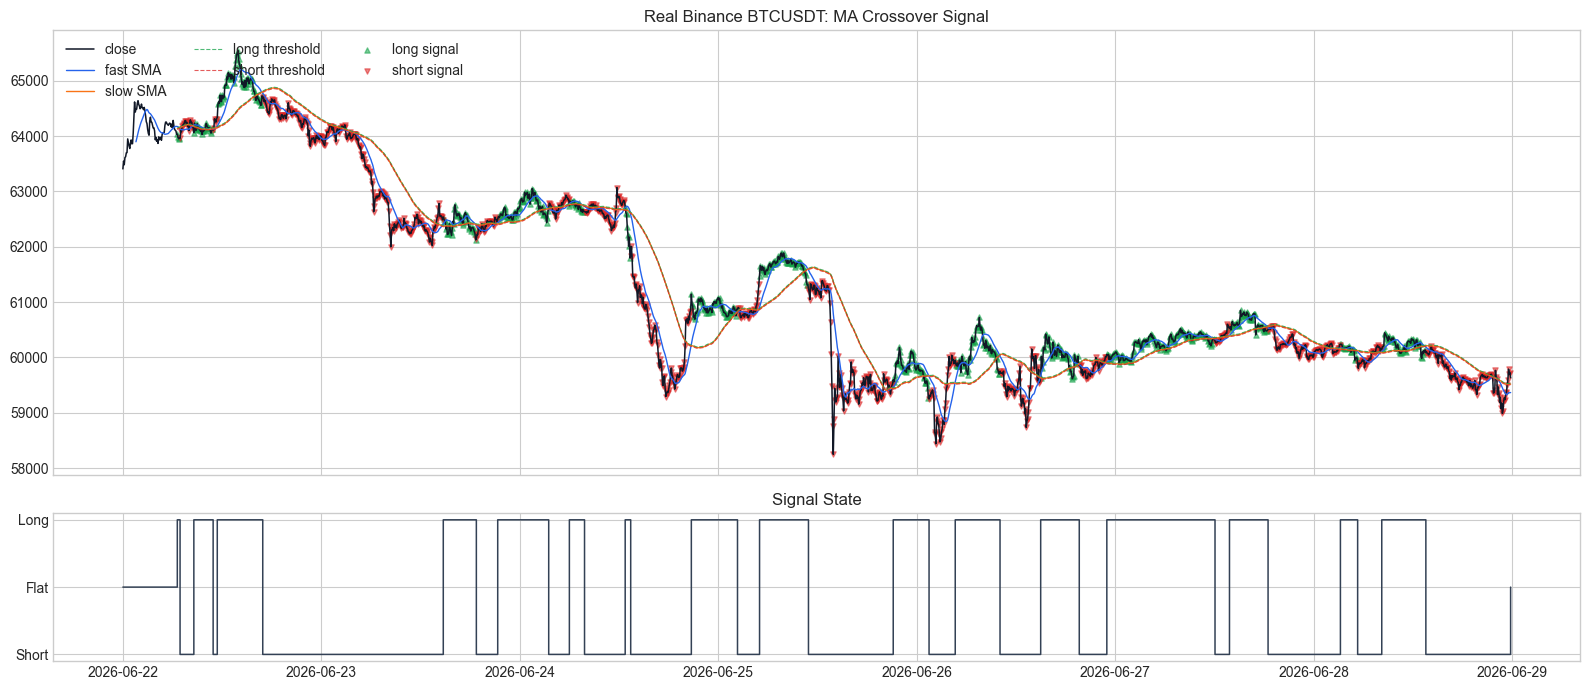

In [8]:
fig, axes = plot_ma_signal_panel(ma_result, 'Real Binance BTCUSDT: MA Crossover Signal')
plt.show()

가격, Fast SMA, Slow SMA를 함께 보면 MA Crossover의 장단점이 동시에 보인다. 가격이 한 방향으로 충분히 움직이는 구간에서는 Fast SMA가 Slow SMA 위/아래로 벌어지며 Long 또는 Short 신호가 비교적 명확하게 나온다.

하지만 방향이 꺾이거나 짧은 반등이 나오는 구간에서는 신호가 늦다. 이동평균은 과거 가격을 평균낸 값이기 때문에, 가격이 이미 움직인 뒤에야 Fast SMA가 반응한다. 이 때문에 하락 이후 반등 구간에서는 늦게 Long으로 바뀌거나, 반등이 끝난 뒤에도 이전 평균의 영향으로 잘못된 방향을 유지할 수 있다.

그래프의 핵심 경향은 **신호가 가격보다 뒤따라간다**는 점이다. 추세가 오래 지속되면 이 후행성이 큰 문제가 되지 않지만, 횡보장이나 전환 구간에서는 늦은 진입과 늦은 청산이 반복되어 손익비가 나빠진다.

## 8. Focus Window: 2026-06-25 13:00 ~ 2026-06-26 14:00
- `2026-06-25 13:00 ~ 15:00`: 첫 방향성은 잘 따라갈 수 있지만, 이후 반등/되돌림에서 신호가 흔들릴 수 있음
- `2026-06-26 13:00 ~ 14:00`: 방향 전환이 발생해도 MA가 후행하기 때문에 늦게 반응할 수 있음

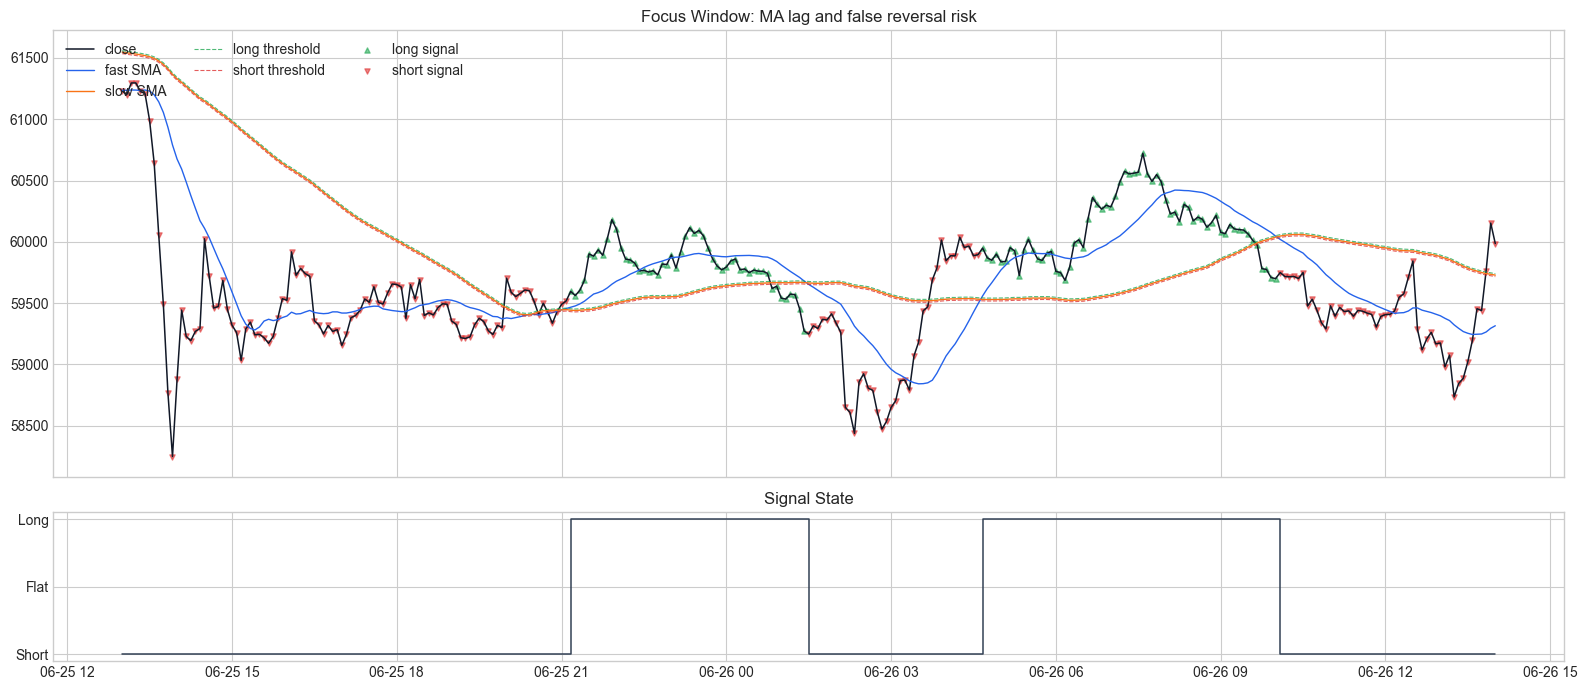

{'rows': 301,
 'signal_flips': 4,
 'long_bars': 117,
 'short_bars': 184,
 'flat_bars': 0,
 'price_return_pct': np.float64(-2.0368168693902677)}

In [9]:
focus_start = pd.Timestamp('2026-06-25 13:00:00')
focus_end = pd.Timestamp('2026-06-26 14:00:00')
focus = ma_result[(ma_result['timestamp'] >= focus_start) & (ma_result['timestamp'] <= focus_end)].copy()

fig, axes = plot_ma_signal_panel(focus, 'Focus Window: MA lag and false reversal risk')
plt.show()

focus_stats = {
    'rows': len(focus),
    'signal_flips': int(focus['signal_change'].sum()),
    'long_bars': int((focus['signal'] == 1).sum()),
    'short_bars': int((focus['signal'] == -1).sum()),
    'flat_bars': int((focus['signal'] == 0).sum()),
    'price_return_pct': (focus['close'].iloc[-1] / focus['close'].iloc[0] - 1.0) * 100 if len(focus) else np.nan,
}
focus_stats

확대 구간(`2026-06-25 13:00 ~ 2026-06-26 14:00`)은 총 **301개 5분봉**으로 구성되어 있고, 이 안에서 MA Crossover는 **4번의 signal flip**을 만들었다. 포지션 상태는 Long **117 bars**, Short **184 bars**, Flat **0 bars**였고, 해당 구간의 가격 수익률은 약 **-2.04%**였다.

이 결과는 두 가지를 보여준다.

첫째, 가격이 전체적으로 하락한 구간이라 Short exposure가 더 많았던 것은 방향성 측면에서 어느 정도 자연스럽다. 하지만 둘째, 문제는 전환 지점이다. 가격이 급락한 뒤 짧게 반등하거나 다시 밀리는 구간에서 MA는 즉각 반응하지 못하고, Fast/Slow 평균이 따라올 때까지 시간이 걸린다.

따라서 이 구간은 MA Crossover가 “큰 방향성은 어느 정도 따라갈 수 있지만, 방향 전환과 dead-cat bounce 같은 짧은 반대 흐름에는 취약하다”는 점을 보여준다. 즉, MA 신호만으로는 지금이 추세 지속 구간인지, 일시 반등인지, 박스 전환 구간인지 구분하기 어렵다.

## 9. Band Sensitivity

`neutral_band_bps`를 키우면 작은 노이즈에는 덜 반응한다. 하지만 너무 크게 잡으면 추세 진입이 늦어진다.

이 셀에서는 band 크기를 바꿔가며 다음을 비교한다.

- signal flips
- total cost paid
- total return
- MDD
- PF

In [10]:
band_metrics = {}
band_results = {}
for bps in [0.0, 2.0, 5.0, 10.0, 20.0, 40.0]:
    frame = add_ma_crossover_features(
        price_df,
        fast_window=20,
        slow_window=80,
        neutral_band_bps=bps,
        exit_on_neutral=False,
    )
    result, trades, metrics = run_vector_ma_backtest(frame, initial_equity=10_000.0, notional=1_000.0, cost_bps=7.0)
    band_metrics[f'band_{bps:g}bps'] = metrics
    band_results[f'band_{bps:g}bps'] = result

band_summary = metrics_table(band_metrics)
band_summary

,scenario,total_return_pct,win_rate_pct,profit_factor,max_drawdown_pct,total_trades,signal_flips,total_cost_paid
0,band_0bps,-0.568840,23.076923,0.751504,-0.899594,39.0,41.0,55.3
1,band_2bps,-0.367644,25.806452,0.616924,-0.807830,31.0,33.0,44.1
2,band_5bps,-0.165415,27.586207,0.752419,-0.725166,29.0,31.0,41.3
3,band_10bps,-0.431881,20.833333,0.648080,-1.006080,24.0,26.0,34.3
4,band_20bps,0.173612,33.333333,1.244352,-0.819685,15.0,17.0,21.7
5,band_40bps,-0.245239,45.454545,0.565744,-1.035997,11.0,13.0,16.1


Band sensitivity 결과는 MA Crossover가 파라미터 선택에 민감하다는 점을 보여준다.

| Band | TR | Win Rate | PF | MDD | Trades | Signal Flips | Cost |
|---|---:|---:|---:|---:|---:|---:|---:|
| 0bps | -0.57% | 23.08% | 0.75 | -0.90% | 39 | 41 | 55.3 |
| 2bps | -0.37% | 25.81% | 0.62 | -0.81% | 31 | 33 | 44.1 |
| 5bps | -0.17% | 27.59% | 0.75 | -0.73% | 29 | 31 | 41.3 |
| 10bps | -0.43% | 20.83% | 0.65 | -1.01% | 24 | 26 | 34.3 |
| 20bps | **+0.17%** | 33.33% | **1.24** | -0.82% | 15 | 17 | 21.7 |
| 40bps | -0.25% | 45.45% | 0.57 | -1.04% | 11 | 13 | 16.1 |

Band가 커질수록 거래 수와 signal flip, 비용은 줄어드는 경향이 있다. 예를 들어 0bps에서는 39 trades / 41 flips / cost 55.3이지만, 40bps에서는 11 trades / 13 flips / cost 16.1로 크게 감소한다.

다만 성과는 단조롭게 좋아지지 않는다. 20bps에서는 유일하게 TR이 양수이고 PF도 1.24로 개선되지만, 40bps에서는 승률은 높아졌음에도 PF가 0.57로 악화된다. 이는 band를 키우면 노이즈는 줄일 수 있지만, 좋은 추세 진입까지 놓치거나 너무 늦게 들어갈 수 있음을 의미한다.

결론적으로 이 결과는 “band를 크게 잡으면 해결된다”가 아니라, **MA Crossover는 노이즈 회피와 진입 지연 사이의 trade-off가 크고, 단순 파라미터 조정만으로 안정적인 개선을 보장하기 어렵다**는 것을 보여준다.

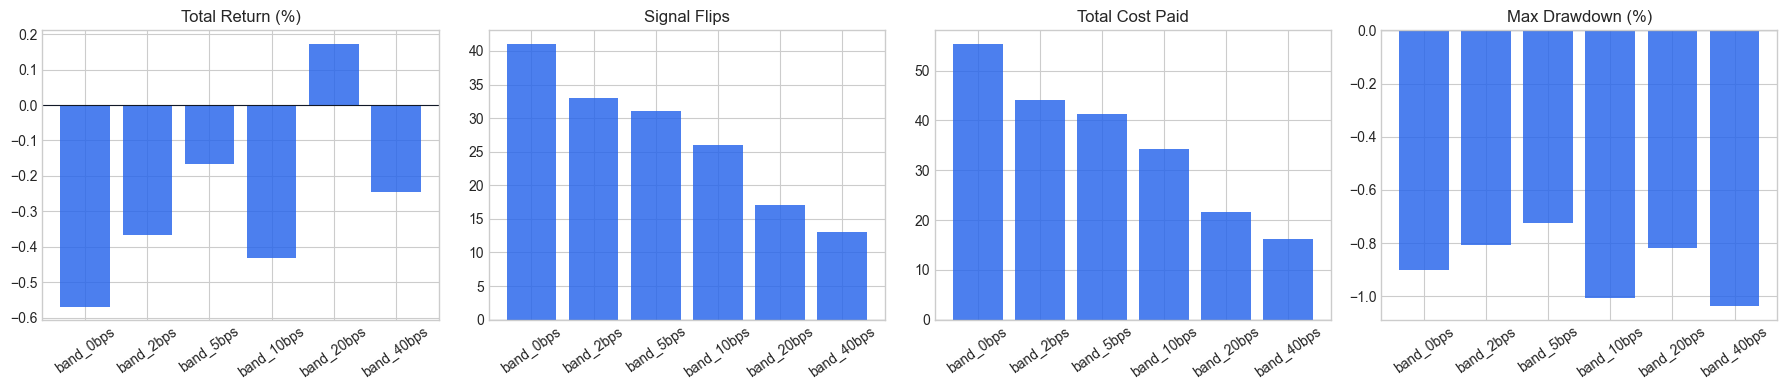

In [11]:
fig, axes = plt.subplots(1, 4, figsize=(18, 4))
plot_cols = [
    ('total_return_pct', 'Total Return (%)'),
    ('signal_flips', 'Signal Flips'),
    ('total_cost_paid', 'Total Cost Paid'),
    ('max_drawdown_pct', 'Max Drawdown (%)'),
]
for ax, (col, title) in zip(axes, plot_cols):
    ax.bar(band_summary['scenario'], band_summary[col], color='#2563EB', alpha=0.82)
    ax.set_title(title)
    ax.tick_params(axis='x', rotation=35)
    ax.axhline(0, color='#111827', linewidth=0.8)
plt.tight_layout()
plt.show()

그래프에서는 band가 커질수록 signal flips와 total cost가 줄어드는 모습이 직관적으로 보인다. 완충지대가 넓어지면 Fast MA와 Slow MA가 아주 작게 벌어지는 구간을 무시하기 때문에, 작은 노이즈에 의한 포지션 전환은 줄어든다.

하지만 Total Return과 MDD는 band 크기에 따라 일관적으로 개선되지 않는다. 특히 20bps는 가장 좋은 조합으로 보이지만, 40bps에서는 거래 수가 더 줄었음에도 성과가 다시 악화된다. 이는 너무 둔감한 신호가 추세 초입을 놓치거나 청산을 늦출 수 있기 때문이다.

따라서 이 그래프의 메시지는 명확하다. MA Crossover의 약점은 단순히 band가 너무 작아서 생긴 문제가 아니라, **가격 평균만으로는 시장이 range인지 transition인지 trend인지 구분하지 못한다는 구조적 한계**에 가깝다.